<a href="https://colab.research.google.com/github/raghavrakesh20/Small-projects-practice./blob/main/siddi_goma_dhamal_tokenization_audit_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the required NLP libraries for the Architectural Audit
!pip install transformers torch sentencepiece pandas

In [2]:
import torch
from transformers import AutoTokenizer

print("Loading Global Tokenizers... (this takes a few seconds)")

# 1. Load the SOTA Global Tokenizers
# mBERT (WordPiece baseline)
mbert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

# Llama-3 (BPE baseline) - Using the open research mirror to bypass the password wall
llama_tokenizer = AutoTokenizer.from_pretrained("NousResearch/Meta-Llama-3-8B")

# 2. Load your Gold Standard Siddi Corpus
file_name = 'Lyrics_Siddi.txt'

try:
    with open(file_name, 'r', encoding='utf-8') as f:
        lyrics = [line.strip() for line in f if line.strip()]

    def calculate_fertility(text, tokenizer):
        words = text.split()
        tokens = tokenizer.tokenize(text)
        # Fertility Rate = Total Tokens / Total Words
        return len(tokens) / len(words) if len(words) > 0 else 0

    # 3. Execute the Audit and Print the Results
    print("\n--- ARCHITECTURAL AUDIT: FERTILITY RATE ---")
    print(f"{'Performative Phrase':<35} | {'mBERT (Global)':<15} | {'Llama-3 (SOTA)':<15}")
    print("-" * 75)

    # Testing the first 15 lines of your performance data
    for line in lyrics[:15]:
        mbert_score = calculate_fertility(line, mbert_tokenizer)
        llama_score = calculate_fertility(line, llama_tokenizer)
        print(f"{line[:33]:<35} | {mbert_score:<15.2f} | {llama_score:<15.2f}")

except FileNotFoundError:
    print(f"\nERROR: Could not find '{file_name}'.")
    print("Colab resets its files when you close it. Please click the Folder icon on the left and re-upload 'Lyrics_Siddi.txt'.")

Loading Global Tokenizers... (this takes a few seconds)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]


--- ARCHITECTURAL AUDIT: FERTILITY RATE ---
Performative Phrase                 | mBERT (Global)  | Llama-3 (SOTA) 
---------------------------------------------------------------------------
bana ye bana                        | 1.00            | 1.33           
bana yambu jambu sana               | 1.50            | 2.25           
bana ye bana                        | 1.00            | 1.33           
bana ye bana                        | 1.00            | 1.33           
Ye bana                             | 1.00            | 1.00           
peer jungli ho                      | 1.33            | 1.33           
yalla yalla                         | 2.00            | 2.00           
bava jungali bava jungli            | 2.00            | 2.00           
o allah ya allah                    | 1.50            | 1.50           
kya khabar laya o njungli           | 2.20            | 2.20           
kya khabar laya bava jungli         | 2.20            | 2.20           
ban ghum aaya j

In [3]:
import sentencepiece as spm
from transformers import AutoTokenizer

print("Preparing the Architectural Audit Comparison...\n")

# 1. Train the Custom "Contributory" Unigram Model
# We train this directly on your Gold Standard corpus.
# We use a very small vocabulary size (e.g., 60) because the corpus is highly focused.
file_name = 'Lyrics_Siddi.txt'

try:
    spm.SentencePieceTrainer.train(
        input=file_name,
        model_prefix='siddi_unigram',
        vocab_size=60, # Small size for a specialized corpus
        model_type='unigram',
        character_coverage=1.0 # Ensures it captures all characters without dropping any
    )

    # Load your newly trained localized model
    siddi_sp = spm.SentencePieceProcessor(model_file='siddi_unigram.model')

    # Load the Global mBERT tokenizer again for direct comparison
    mbert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

    # 2. Select a highly syncretic/rhythmic test phrase from your lyrics
    test_phrase = "sobilale sobilal ho yale sobilal"

    # 3. Print the Comparison
    print("--- ARCHITECTURAL AUDIT: TOKENIZATION COMPARISON ---")
    print(f"Original Text: '{test_phrase}'\n")

    print("1. GLOBAL STANDARD (mBERT BPE) - 'Extractive' Framework")
    mbert_tokens = mbert_tokenizer.tokenize(test_phrase)
    print(f"Tokens output: {mbert_tokens}")
    print(f"Total tokens used: {len(mbert_tokens)}\n")

    print("2. SITUATED LOCALIZATION (Custom Unigram) - 'Contributory' Framework")
    # The 'out_type=str' returns the readable text pieces
    siddi_tokens = siddi_sp.encode(test_phrase, out_type=str)
    print(f"Tokens output: {siddi_tokens}")
    print(f"Total tokens used: {len(siddi_tokens)}\n")

    print("--------------------------------------------------")
    print("Note: The '_' symbol in the custom model represents the natural start of a whole word/rhythmic unit.")

except FileNotFoundError:
    print(f"\nERROR: Could not find '{file_name}'. Please ensure it is still uploaded to Colab.")
except Exception as e:
    print(f"\nAn error occurred during training: {e}")
    print("If you get a 'vocab_size' error, try lowering the vocab_size number to 50 or 40 in the code.")

Preparing the Architectural Audit Comparison...

--- ARCHITECTURAL AUDIT: TOKENIZATION COMPARISON ---
Original Text: 'sobilale sobilal ho yale sobilal'

1. GLOBAL STANDARD (mBERT BPE) - 'Extractive' Framework
Tokens output: ['sob', '##ila', '##le', 'sob', '##ila', '##l', 'ho', 'ya', '##le', 'sob', '##ila', '##l']
Total tokens used: 12

2. SITUATED LOCALIZATION (Custom Unigram) - 'Contributory' Framework
Tokens output: ['▁sobilale', '▁sobilal', '▁ho', '▁yale', '▁sobilal']
Total tokens used: 5

--------------------------------------------------
Note: The '_' symbol in the custom model represents the natural start of a whole word/rhythmic unit.


Temporal-Dialogic Mapping

In [4]:
# Install the required State-of-the-Art NLP libraries
!pip install transformers torch sentencepiece pandas

In [5]:
import pandas as pd

# Load the Enriched Metadata Corpus you just generated
file_name = 'Siddi_Mapping.csv'

try:
    df = pd.read_csv(file_name)

    print("--- EXPERIMENT 2: TEMPORAL-DIALOGIC MAPPING (TWO-VERSE AUDIT) ---\n")

    # 1. Simulate the "Extractive AI" view (Standard Global AI)
    print("1. THE 'EXTRACTIVE AI' PIPELINE (Standard AI)")
    print("AI sees only text. It ignores the indigenous 1-to-100 velocity scale.")
    print("-" * 80)

    ai_memory = {}
    for index, row in df.iterrows():
        text = row['Phrase']
        if text not in ai_memory:
            ai_memory[text] = "Translated as static dictionary text"
        print(f"Input: '{text:<18}' -> AI Output: {ai_memory[text]}")

    print("\n" + "="*80 + "\n")

    # 2. Simulate the "Contributory AI" view (Situated Localization)
    print("2. THE 'CONTRIBUTORY' FRAMEWORK (Ontological Alignment)")
    print("Model processes Text + Velocity (1-100) + Ritual Context.")
    print("-" * 80)

    for index, row in df.iterrows():
        # Highlighting the shifts for the two specific verses
        if row['Temporal_Velocity'] == 100:
            status = " [HEIGHTENED CLIMAX: Embodying Ritual Action]"
        elif row['Temporal_Velocity'] >= 80:
            status = " [SHIFT: Lyrics dissolve into drumbeats]"
        else:
            status = ""

        print(f"Vel: {row['Temporal_Velocity']:<3} | Role: {row['Dialogic_Role']:<16} | Text: '{row['Phrase']:<18}' -> State: {row['Semantic_State']}{status}")

except FileNotFoundError:
    print(f"Error: Could not find '{file_name}'. Please ensure it is uploaded to the Colab files section.")

--- EXPERIMENT 2: TEMPORAL-DIALOGIC MAPPING (TWO-VERSE AUDIT) ---

1. THE 'EXTRACTIVE AI' PIPELINE (Standard AI)
AI sees only text. It ignores the indigenous 1-to-100 velocity scale.
--------------------------------------------------------------------------------
Input: 'sobilale sobilal  ' -> AI Output: Translated as static dictionary text
Input: 'ho yale sobilal   ' -> AI Output: Translated as static dictionary text
Input: 'sobilale sobilal  ' -> AI Output: Translated as static dictionary text
Input: 'ho yale sobilal   ' -> AI Output: Translated as static dictionary text
Input: 'sobilale sobilal  ' -> AI Output: Translated as static dictionary text
Input: 'ho yale sobilal   ' -> AI Output: Translated as static dictionary text
Input: 'Gor gor           ' -> AI Output: Translated as static dictionary text
Input: 'Bava gor          ' -> AI Output: Translated as static dictionary text


2. THE 'CONTRIBUTORY' FRAMEWORK (Ontological Alignment)
Model processes Text + Velocity (1-100) + Ritu

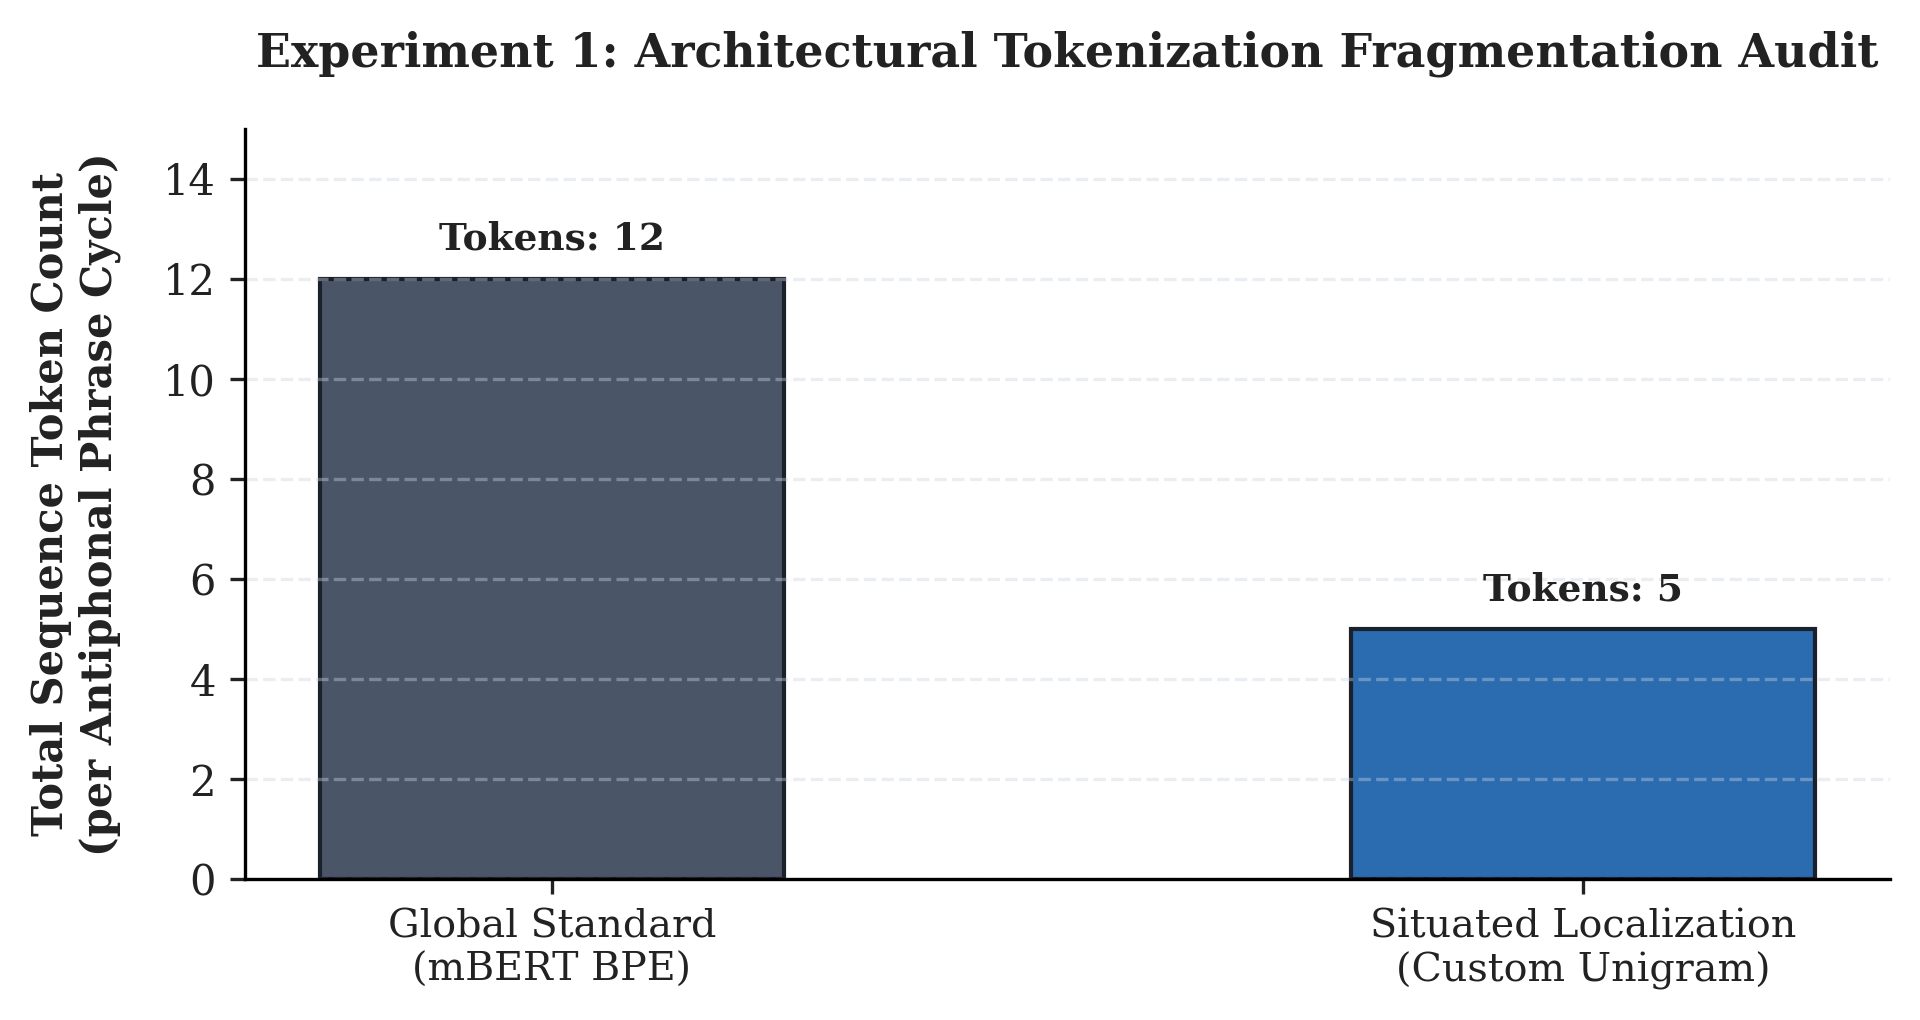

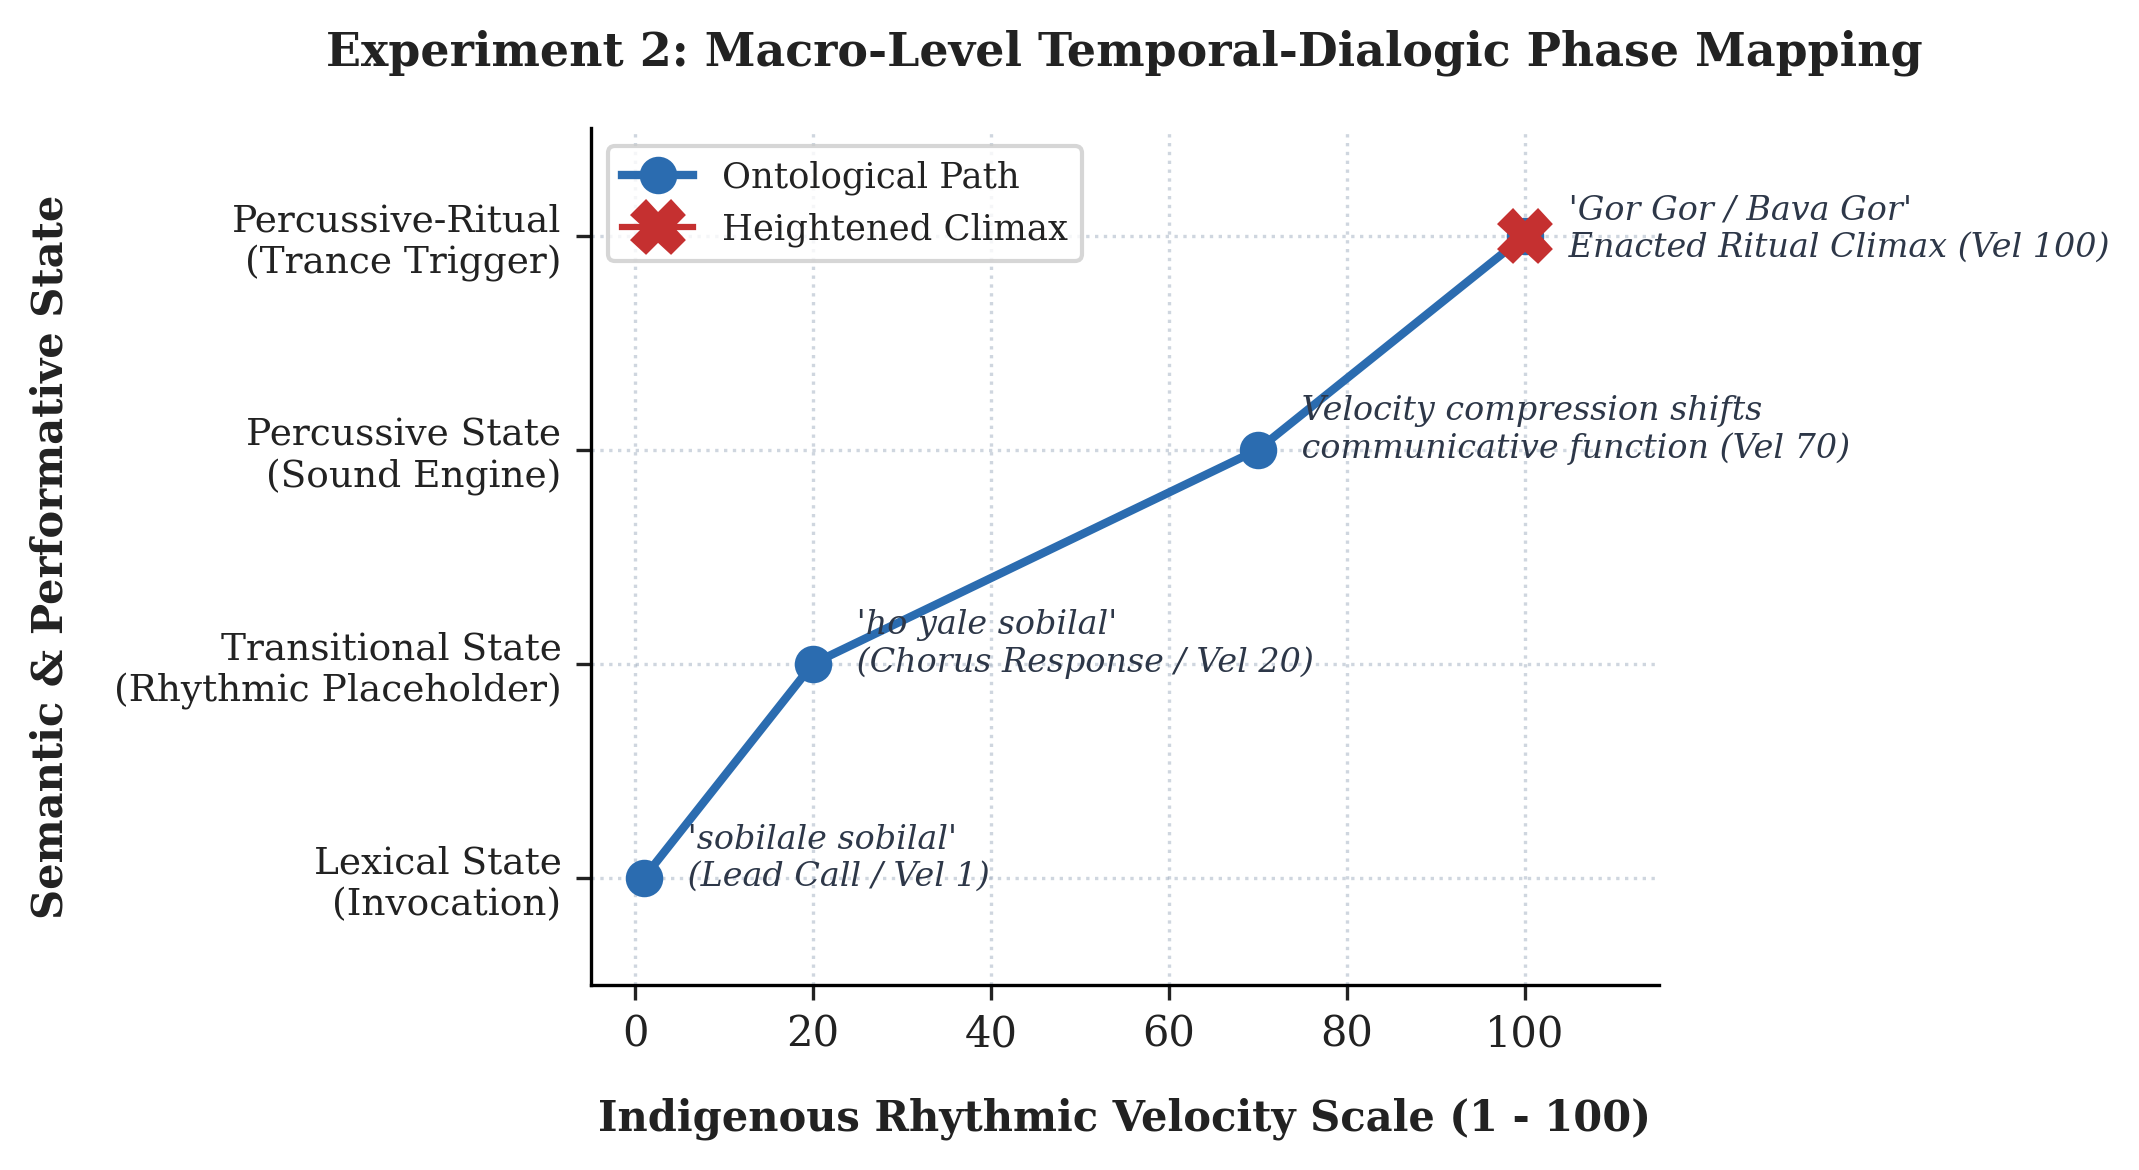

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Set global academic plotting styles for maximum clarity
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.color'] = '#222222'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color'] = '#222222'
plt.rcParams['ytick.color'] = '#222222'

# ==============================================================================
# FIGURE 1: SEQUENCE FRAGMENTATION & COMPUTATIONAL ENTROPY (EXPERIMENT 1)
# ==============================================================================
fig1, ax1 = plt.subplots(figsize=(6.5, 3.5), dpi=300)

models = ['Global Standard\n(mBERT BPE)', 'Situated Localization\n(Custom Unigram)']
token_counts = [12, 5]

x = np.arange(len(models))
width = 0.45

# Using a muted academic palette (Charcoal Grey vs. Deep Slate Blue)
colors = ['#4A5568', '#2B6CB0']

bars = ax1.bar(x, token_counts, width, color=colors, edgecolor='#1A202C', linewidth=1)

# Structural adjustments to ground the data in indigenous performative cycles
ax1.set_ylabel('Total Sequence Token Count\n(per Antiphonal Phrase Cycle)', fontsize=10, fontweight='bold', labelpad=10)
ax1.set_title('Experiment 1: Architectural Tokenization Fragmentation Audit', fontsize=11, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=9.5)
ax1.set_ylim(0, 15)
ax1.grid(axis='y', linestyle='--', alpha=0.4, color='#CBD5E0')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add annotations to display exact token allocation metrics
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'Tokens: {height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5),  # 5 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Siddi_Tokenization_Indigenous_Audit.png', bbox_inches='tight', dpi=300)
plt.show()

# ==============================================================================
# FIGURE 2: TEMPORAL-DIALOGIC SCALE MAPPING (EXPERIMENT 2)
# ==============================================================================
fig2, ax2 = plt.subplots(figsize=(7, 4), dpi=300)

# Map the coordinates directly from your temporal-dialogic mapping matrix
velocities = [1, 20, 70, 100]
states_numeric = [1, 2, 3, 4]
state_labels = ['Lexical State\n(Invocation)', 'Transitional State\n(Rhythmic Placeholder)', 'Percussive State\n(Sound Engine)', 'Percussive-Ritual\n(Trance Trigger)']

# Plot the phase transition line tracking the momentum of the performance
ax2.plot(velocities, states_numeric, marker='o', color='#2B6CB0', linestyle='-', linewidth=2, markersize=8, label='Ontological Path')

# Emphasize the heightened climax at velocity 100
ax2.plot(100, 4, marker='X', color='#C53030', markersize=12, label='Heightened Climax')

# Native labeling and critical data framing
ax2.set_xlabel('Indigenous Rhythmic Velocity Scale (1 - 100)', fontsize=10, fontweight='bold', labelpad=10)
ax2.set_ylabel('Semantic & Performative State', fontsize=10, fontweight='bold', labelpad=10)
ax2.set_title('Experiment 2: Macro-Level Temporal-Dialogic Phase Mapping', fontsize=11, fontweight='bold', pad=15)

ax2.set_xlim(-5, 115)
ax2.set_ylim(0.5, 4.5)
ax2.set_yticks(states_numeric)
ax2.set_yticklabels(state_labels, fontsize=9)

# Add structural annotations tracking interactive performative turns
annotations = [
    " 'sobilale sobilal' \n (Lead Call / Vel 1)",
    " 'ho yale sobilal' \n (Chorus Response / Vel 20)",
    " Velocity compression shifts \n communicative function (Vel 70)",
    " 'Gor Gor / Bava Gor' \n Enacted Ritual Climax (Vel 100)"
]

for idx, (vel, state) in enumerate(zip(velocities, states_numeric)):
    ax2.annotate(annotations[idx], (vel, state), xytext=(8, -5 if idx==3 else -2),
                 textcoords='offset points', fontsize=8, style='italic', color='#2D3748')

ax2.grid(True, linestyle=':', alpha=0.5, color='#A0AEC0')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc='upper left', frameon=True, fontsize=8.5)

plt.tight_layout()
plt.savefig('Siddi_Temporal_Indigenous_Mapping.png', bbox_inches='tight', dpi=300)
plt.show()